In [2]:
import numpy as np
import pennylane as qml

## Defining the device
Pennylane uses a [device](https://pennylane.ai/devices) to simulate a quantum computer. We use the `lightning.qubit` device here. The `wires` argument defines the number of qubits in the device.

In [3]:
dev = qml.device('lightning.qubit',wires=1)

## Intro to QNodes
Every *circuit* in pennylane is a python function wrapped in a [Pennylane Qnode](https://docs.pennylane.ai/en/stable/code/api/pennylane.QNode.html). 

By default every qubit is initialized to the $\ket{0}$ state. Lets start by creating a simple circuit to flip the qubit state.

In [6]:
@qml.qnode(dev)
def flipper():
    qml.X(wires=0) # We apply the Pauli-X gate on the first qubit
    return qml.state() # Return the state of the circuit

In [9]:
flipper() # This calls the circuit

tensor([0.+0.j, 1.+0.j], requires_grad=True)

As we can see this is the $\ket{1}$ state. The `qml.state()` function returns a list of coefficients for the corresponding basis states.

#### Visualize the Circuit
Pennylane provides an utility function to visualize our circuit

(<Figure size 400x200 with 1 Axes>, <Axes: >)

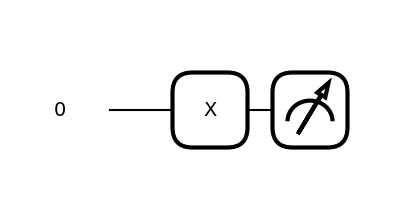

In [7]:
qml.draw_mpl(flipper)()

As we can see we have just applied the $X$ gate.

## Passing Arguments to circuits
We can pass arguments to qnodes just like normal python functions !

Let's create a Qnode which takes a boolean `x` as an input and flips the qubit state based on this boolean. This is also known as [**basis state encoding**](https://pennylane.ai/qml/glossary/quantum_embedding).

In [10]:
@qml.qnode(dev)
def flipper2(x:bool):
    if(x):
        qml.X(0)
    return qml.state()

In [11]:
flipper2(True)

tensor([0.+0.j, 1.+0.j], requires_grad=True)

In [12]:
flipper2(False)

tensor([1.+0.j, 0.+0.j], requires_grad=True)

As we can see the function flips the state based on the boolean that we pass to it.

## Applying Multiple Gates
Lets now create the circuit which applies the `H`, `Z` and `X` gates in that order. We should expect the state :
$$
    \ket{\psi} = \frac{1}{\sqrt{2}}(-\ket{0} + \ket{1})
$$

In [13]:
@qml.qnode(dev)
def multiple_gates():
    qml.Hadamard(0)
    qml.Z(0)
    qml.X(0)
    return qml.state()

In [14]:
multiple_gates()

tensor([-0.70710678-0.j,  0.70710678+0.j], requires_grad=True)

# Code it yourself !!!

### 1. Rotational Encoding
Write a Qnode to perform [**rotational encoding**](https://pennylane.ai/qml/glossary/quantum_embedding) using the $R_Y$-gate. This involves encoding a variable `x` as the angle to the $R-Y$ gate -
$$
    \ket{\psi(x)} = R_Y(x)\ket{0}
$$

In [15]:
# Code here

### 2. Gate Computation
Write a qndoe to apply the gates `[X,H,Z,H]`

In [16]:
# Code here

### 3. Classical Controlled Gates
Write a Qnode to take 3 boolean inputs `x`,`y`, and `z`, and then apply the $S$, $T$ and $Y$ gates respectively based on the boolean.